In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import _tree

warnings.filterwarnings('ignore')

breast_cancer = load_breast_cancer()
feature_names = breast_cancer.feature_names

X = pd.DataFrame(breast_cancer.data, columns=feature_names)
y = pd.Series(breast_cancer.target, name='target')

print("Shape of dataset:", X.shape)
print("\nClass counts:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Shape of dataset: (569, 30)

Class counts:
target
1    357
0    212
Name: count, dtype: int64

Training set size: 455
Test set size: 114


Random Forest Results
----------------------------------------
Accuracy : 0.9561
F1 Score : 0.9655

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



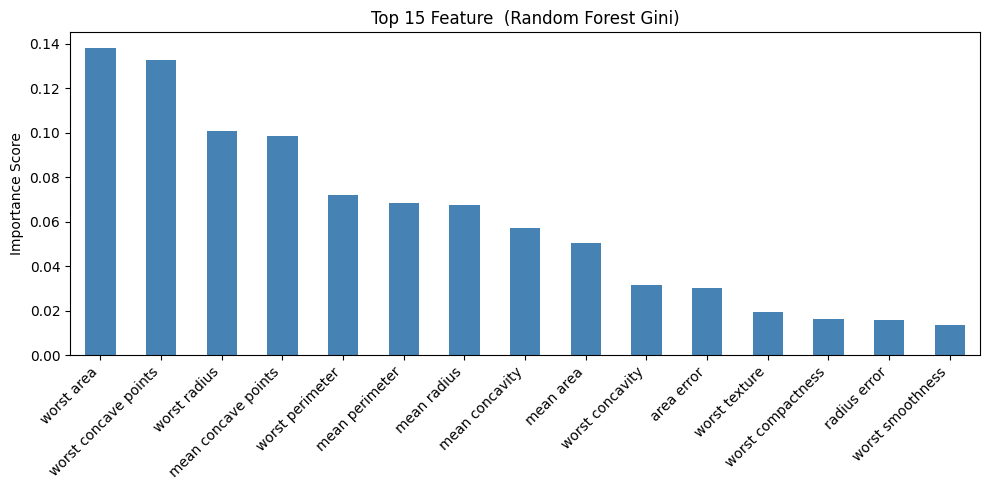

In [5]:
forest = RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42,n_jobs=-1
)
forest.fit(X_train, y_train)

predictions = forest.predict(X_test)
acc = accuracy_score(y_test, predictions)
f1  = f1_score(y_test, predictions)

print("Random Forest Results")
print("-" * 40)
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print()
print(classification_report(y_test, predictions,
      target_names=["Malignant", "Benign"]))

feature_imp = pd.Series(
    forest.feature_importances_,
    index=breast_cancer.feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feature_imp.head(15).plot(kind='bar', color='steelblue')
plt.title("Top 15 Feature  (Random Forest Gini)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rf_importances.png', dpi=150)
plt.show()